In [1]:
# Quick check - do we have our data from Notebook 1?
import pandas as pd
import os

# Check if cleaned data exists
if os.path.exists('cleaned_prices_2015_2024.csv'):
    print("✅ Data file found! Ready to start Notebook 2.")
    # Preview the data
    prices = pd.read_csv('cleaned_prices_2015_2024.csv', index_col=0, parse_dates=True)
    print(f"\n📊 Loaded {len(prices)} days of data for {len(prices.columns)} assets")
    print(f"Assets: {list(prices.columns)}")
else:
    print("❌ Data file not found. You may need to run Notebook 1 first.")

✅ Data file found! Ready to start Notebook 2.

📊 Loaded 2515 days of data for 6 assets
Assets: ['AAPL', 'EFA', 'GLD', 'SPY', 'TLT', 'XLE']


In [2]:
# ============================================
# NOTEBOOK 2: RETURNS & RISK ANALYSIS
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*60)
print("📊 PYTHON FINANCIAL ANALYSIS PROJECT")
print("="*60)
print("Notebook 2: Returns & Risk Analysis")
print("Author: Jonathan Nadeau")
print(f"Date: {datetime.now().strftime('%B %d, %Y')}")
print("="*60)
print("\n✅ All libraries imported successfully!")
print("\nThis notebook analyzes:")
print("  • Daily, monthly, and cumulative returns")
print("  • Risk metrics (volatility, Sharpe ratio)")
print("  • Maximum drawdown analysis")
print("  • Risk-return tradeoffs")
print("\n" + "="*60)

📊 PYTHON FINANCIAL ANALYSIS PROJECT
Notebook 2: Returns & Risk Analysis
Author: Jonathan Nadeau
Date: February 12, 2026

✅ All libraries imported successfully!

This notebook analyzes:
  • Daily, monthly, and cumulative returns
  • Risk metrics (volatility, Sharpe ratio)
  • Maximum drawdown analysis
  • Risk-return tradeoffs



In [3]:
# ============================================
# SECTION 2: CALCULATE RETURNS
# ============================================

print("📈 CALCULATING RETURNS")
print("="*60)

# Calculate daily returns (percent change day-to-day)
daily_returns = prices.pct_change().dropna()

print("✅ Daily returns calculated")
print(f"   Shape: {daily_returns.shape[0]} days × {daily_returns.shape[1]} assets")
print(f"   Date range: {daily_returns.index[0].strftime('%Y-%m-%d')} to {daily_returns.index[-1].strftime('%Y-%m-%d')}")

# Calculate cumulative returns (buy-and-hold performance)
cumulative_returns = (1 + daily_returns).cumprod()

print("\n✅ Cumulative returns calculated")
print(f"   Starting value: $1.00 invested on {cumulative_returns.index[0].strftime('%B %d, %Y')}")

# Show final values (what $1 became)
print("\n💰 FINAL VALUES ($1 invested in 2015):")
final_values = cumulative_returns.iloc[-1].sort_values(ascending=False)
for ticker, value in final_values.items():
    profit = (value - 1) * 100
    print(f"   ${ticker}: ${value:.2f} (${profit:+.1f}%)")

# Preview daily returns
print("\n📊 Sample Daily Returns (First 5 Days):")
print(daily_returns.head())

print("\n" + "="*60)

📈 CALCULATING RETURNS
✅ Daily returns calculated
   Shape: 2514 days × 6 assets
   Date range: 2015-01-05 to 2024-12-30

✅ Cumulative returns calculated
   Starting value: $1.00 invested on January 05, 2015

💰 FINAL VALUES ($1 invested in 2015):
   $AAPL: $10.36 ($+935.8%)
   $SPY: $3.41 ($+240.8%)
   $GLD: $2.11 ($+110.9%)
   $EFA: $1.67 ($+66.7%)
   $XLE: $1.59 ($+59.1%)
   $TLT: $0.89 ($-11.3%)

📊 Sample Daily Returns (First 5 Days):
                AAPL       EFA       GLD       SPY       TLT       XLE
Date                                                                  
2015-01-05 -0.028171 -0.023605  0.015077 -0.018060  0.015708 -0.041368
2015-01-06  0.000094 -0.011327  0.011399 -0.009419  0.018017 -0.014690
2015-01-07  0.014022  0.011115 -0.005891  0.012461 -0.001974  0.002130
2015-01-08  0.038422  0.013529 -0.004209  0.017745 -0.013243  0.022450
2015-01-09  0.001073 -0.004839  0.011385 -0.008014  0.010952 -0.007926



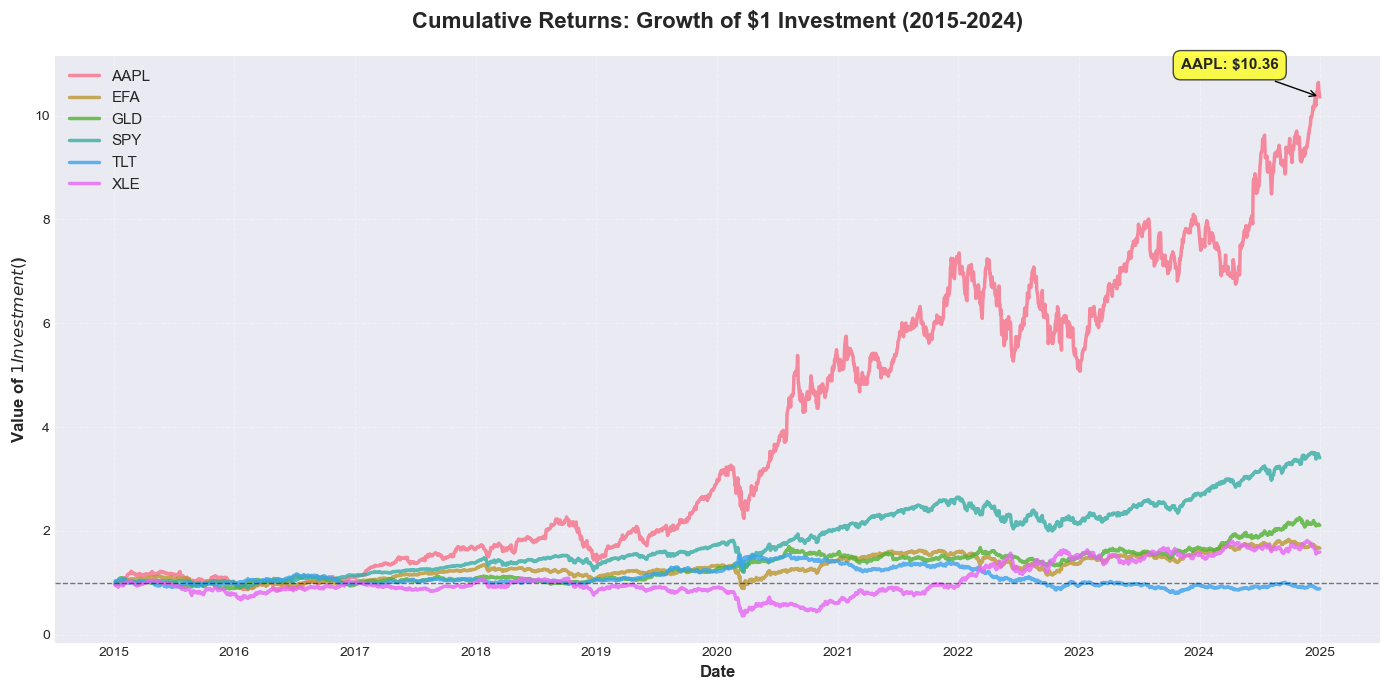

✅ Cumulative returns chart saved as 'python_cumulative_returns.png'

💡 KEY OBSERVATIONS:
  • AAPL delivered the highest cumulative return ($10.36)
  • COVID-19 crash visible in March 2020 (sharp drop)
  • All assets except TLT ended above $1 (positive returns)
  • Growth was not linear - significant volatility throughout


In [4]:
# ============================================
# SECTION 3: CUMULATIVE RETURNS VISUALIZATION
# ============================================

# Create the cumulative returns chart
plt.figure(figsize=(14, 7))

for column in cumulative_returns.columns:
    plt.plot(cumulative_returns.index, cumulative_returns[column], 
             label=column, linewidth=2.5, alpha=0.8)

# Formatting
plt.title('Cumulative Returns: Growth of $1 Investment (2015-2024)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Value of $1 Investment ($)', fontsize=12, fontweight='bold')
plt.legend(loc='upper left', fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--')
plt.axhline(y=1, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Break-even')

# Add annotation for best performer
best_asset = cumulative_returns.iloc[-1].idxmax()
best_value = cumulative_returns.iloc[-1].max()
plt.annotate(f'{best_asset}: ${best_value:.2f}', 
             xy=(cumulative_returns.index[-1], best_value),
             xytext=(-100, 20), textcoords='offset points',
             fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

plt.tight_layout()

# Save the figure
plt.savefig('python_cumulative_returns.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Cumulative returns chart saved as 'python_cumulative_returns.png'")
print("\n💡 KEY OBSERVATIONS:")
print(f"  • {best_asset} delivered the highest cumulative return (${best_value:.2f})")
print("  • COVID-19 crash visible in March 2020 (sharp drop)")
print("  • All assets except TLT ended above $1 (positive returns)")
print("  • Growth was not linear - significant volatility throughout")

In [5]:
# ============================================
# SECTION 4: VOLATILITY & SHARPE RATIO
# ============================================

print("📉 CALCULATING RISK METRICS")
print("="*60)

# Calculate annualized volatility (standard deviation of returns)
# 252 = typical trading days per year
annualized_volatility = daily_returns.std() * np.sqrt(252) * 100

print("✅ Volatility calculated (annualized)")
print("\n📊 VOLATILITY RANKING (Risk from highest to lowest):")
volatility_sorted = annualized_volatility.sort_values(ascending=False)
for ticker, vol in volatility_sorted.items():
    print(f"   {ticker}: {vol:.2f}% annual volatility")

# Calculate annualized returns (from Notebook 1 logic)
years = (prices.index[-1] - prices.index[0]).days / 365.25
annualized_returns = ((prices.iloc[-1] / prices.iloc[0]) ** (1/years) - 1) * 100

print("\n💰 ANNUALIZED RETURNS:")
returns_sorted = annualized_returns.sort_values(ascending=False)
for ticker, ret in returns_sorted.items():
    print(f"   {ticker}: {ret:.2f}% per year")

# Calculate Sharpe Ratio (risk-adjusted return)
# Sharpe = (Return - Risk-free rate) / Volatility
# Using 2% as risk-free rate (typical T-bill rate)
risk_free_rate = 2.0

sharpe_ratios = (annualized_returns - risk_free_rate) / annualized_volatility

print("\n⭐ SHARPE RATIO (Risk-Adjusted Returns):")
print("   Higher is better - measures return per unit of risk")
sharpe_sorted = sharpe_ratios.sort_values(ascending=False)
for ticker, sharpe in sharpe_sorted.items():
    print(f"   {ticker}: {sharpe:.3f}")

# Create summary table
risk_return_summary = pd.DataFrame({
    'Annual Return (%)': annualized_returns,
    'Volatility (%)': annualized_volatility,
    'Sharpe Ratio': sharpe_ratios
}).sort_values('Sharpe Ratio', ascending=False)

print("\n📋 COMPLETE RISK-RETURN SUMMARY:")
print(risk_return_summary.round(3))

print("\n💡 INTERPRETATION:")
best_sharpe = sharpe_ratios.idxmax()
print(f"  • {best_sharpe} has the best Sharpe ratio ({sharpe_ratios.max():.3f})")
print(f"  • This means {best_sharpe} delivers the most return per unit of risk")
print(f"  • Higher returns don't always mean better risk-adjusted performance!")

print("\n" + "="*60)

📉 CALCULATING RISK METRICS
✅ Volatility calculated (annualized)

📊 VOLATILITY RANKING (Risk from highest to lowest):
   XLE: 29.81% annual volatility
   AAPL: 28.47% annual volatility
   SPY: 17.62% annual volatility
   EFA: 17.28% annual volatility
   TLT: 15.32% annual volatility
   GLD: 14.12% annual volatility

💰 ANNUALIZED RETURNS:
   AAPL: 26.36% per year
   SPY: 13.05% per year
   GLD: 7.75% per year
   EFA: 5.25% per year
   XLE: 4.76% per year
   TLT: -1.19% per year

⭐ SHARPE RATIO (Risk-Adjusted Returns):
   Higher is better - measures return per unit of risk
   AAPL: 0.856
   SPY: 0.627
   GLD: 0.407
   EFA: 0.188
   XLE: 0.092
   TLT: -0.208

📋 COMPLETE RISK-RETURN SUMMARY:
      Annual Return (%)  Volatility (%)  Sharpe Ratio
AAPL             26.357          28.466         0.856
SPY              13.055          17.622         0.627
GLD               7.755          14.122         0.407
EFA               5.249          17.284         0.188
XLE               4.755          2

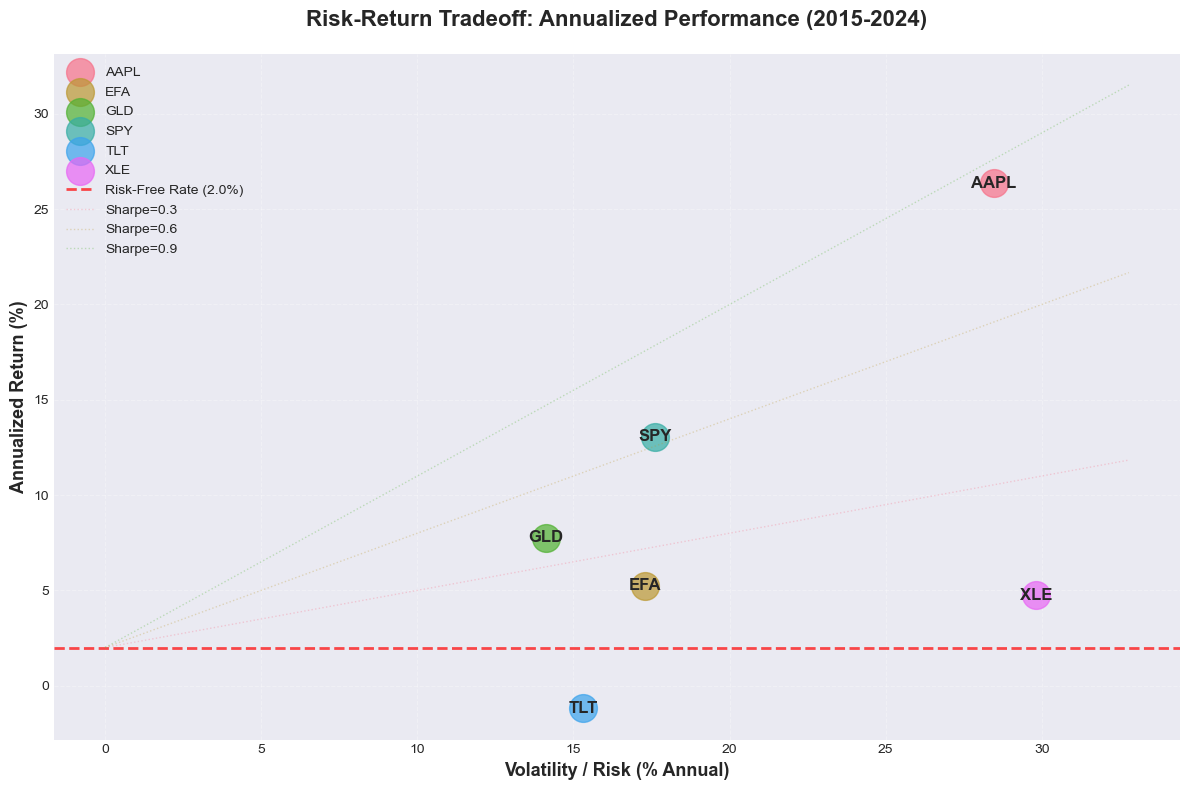

✅ Risk-return scatter plot saved as 'python_risk_return_scatter.png'

💡 READING THE CHART:
  • X-axis = Risk (volatility) - further right = riskier
  • Y-axis = Return - higher up = better returns
  • Upper-left quadrant = IDEAL (high return, low risk)
  • Lower-right quadrant = WORST (low return, high risk)
  • Diagonal lines = Sharpe ratio levels (higher/steeper = better)

🎯 IDEAL POSITION:
  • AAPL is high-risk but delivers exceptional returns
  • SPY offers good returns with moderate risk
  • GLD is low-risk but also low-return (defensive position)


In [6]:
# ============================================
# SECTION 5: RISK-RETURN VISUALIZATION
# ============================================

# Create scatter plot showing risk vs return tradeoff
plt.figure(figsize=(12, 8))

# Plot each asset as a point
for ticker in prices.columns:
    plt.scatter(annualized_volatility[ticker], 
                annualized_returns[ticker],
                s=400, alpha=0.7, label=ticker)
    
    # Add ticker labels
    plt.annotate(ticker, 
                 (annualized_volatility[ticker], annualized_returns[ticker]),
                 fontsize=12, fontweight='bold', ha='center', va='center')

# Formatting
plt.title('Risk-Return Tradeoff: Annualized Performance (2015-2024)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Volatility / Risk (% Annual)', fontsize=13, fontweight='bold')
plt.ylabel('Annualized Return (%)', fontsize=13, fontweight='bold')

# Add risk-free rate line
plt.axhline(y=risk_free_rate, color='red', linestyle='--', 
            linewidth=2, alpha=0.7, label=f'Risk-Free Rate ({risk_free_rate}%)')

# Add diagonal lines showing Sharpe ratios
x_range = np.linspace(0, annualized_volatility.max() * 1.1, 100)
for sharpe_line in [0.3, 0.6, 0.9]:
    y_sharpe = risk_free_rate + sharpe_line * x_range
    plt.plot(x_range, y_sharpe, ':', alpha=0.3, linewidth=1,
             label=f'Sharpe={sharpe_line:.1f}')

plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(loc='upper left', fontsize=10)
plt.tight_layout()

# Save the figure
plt.savefig('python_risk_return_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Risk-return scatter plot saved as 'python_risk_return_scatter.png'")
print("\n💡 READING THE CHART:")
print("  • X-axis = Risk (volatility) - further right = riskier")
print("  • Y-axis = Return - higher up = better returns")
print("  • Upper-left quadrant = IDEAL (high return, low risk)")
print("  • Lower-right quadrant = WORST (low return, high risk)")
print("  • Diagonal lines = Sharpe ratio levels (higher/steeper = better)")
print("\n🎯 IDEAL POSITION:")
print("  • AAPL is high-risk but delivers exceptional returns")
print("  • SPY offers good returns with moderate risk")
print("  • GLD is low-risk but also low-return (defensive position)")

📉 CALCULATING MAXIMUM DRAWDOWN
Maximum Drawdown = Worst peak-to-trough decline
Shows how much an investment fell from its highest point

💔 MAXIMUM DRAWDOWN (Worst decline from peak):
   XLE: -66.81% (fell this much from peak)
   TLT: -48.35% (fell this much from peak)
   AAPL: -38.52% (fell this much from peak)
   EFA: -34.19% (fell this much from peak)
   SPY: -33.72% (fell this much from peak)
   GLD: -22.00% (fell this much from peak)


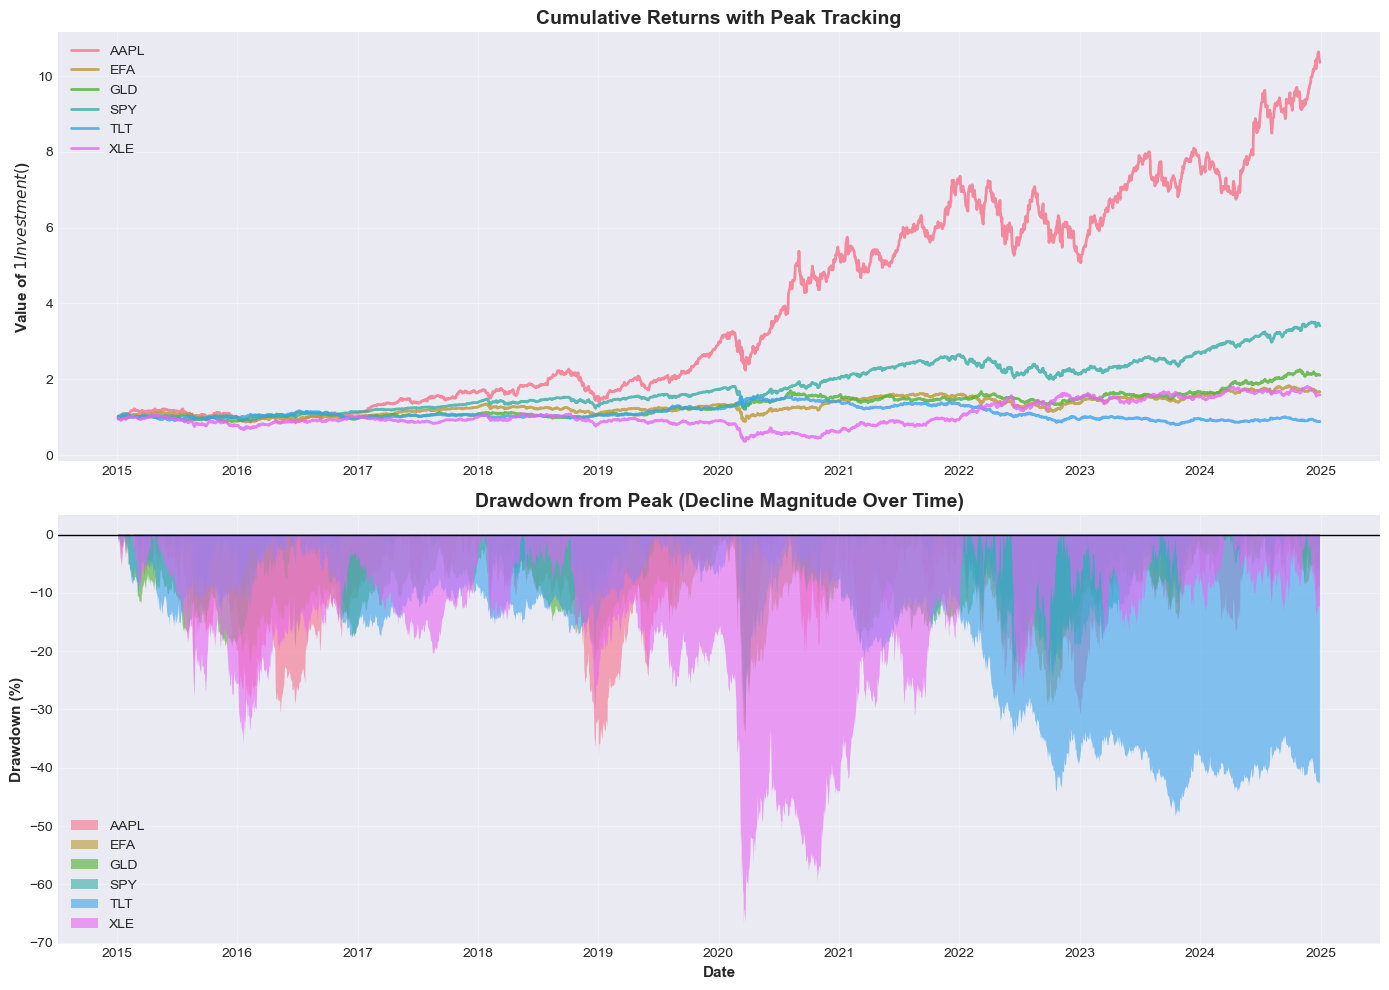


✅ Maximum drawdown chart saved as 'python_maximum_drawdown.png'

💡 KEY INSIGHTS:
  • XLE had the worst drawdown (-66.81%)
  • COVID-19 crash (March 2020) caused the deepest drawdowns
  • Lower drawdown = less pain during market downturns
  • This metric matters for risk management and emotional resilience



In [7]:
# ============================================
# SECTION 6: MAXIMUM DRAWDOWN ANALYSIS
# ============================================

print("📉 CALCULATING MAXIMUM DRAWDOWN")
print("="*60)
print("Maximum Drawdown = Worst peak-to-trough decline")
print("Shows how much an investment fell from its highest point\n")

# Calculate running maximum (highest point so far)
running_max = cumulative_returns.cummax()

# Calculate drawdown (current value vs highest point)
drawdown = (cumulative_returns - running_max) / running_max * 100

# Find maximum drawdown for each asset
max_drawdown = drawdown.min()

print("💔 MAXIMUM DRAWDOWN (Worst decline from peak):")
max_dd_sorted = max_drawdown.sort_values()
for ticker, dd in max_dd_sorted.items():
    print(f"   {ticker}: {dd:.2f}% (fell this much from peak)")

# Visualize drawdown over time
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top chart: Cumulative returns with peaks highlighted
for column in cumulative_returns.columns:
    axes[0].plot(cumulative_returns.index, cumulative_returns[column], 
                 label=column, linewidth=2, alpha=0.8)

axes[0].set_title('Cumulative Returns with Peak Tracking', 
                   fontsize=14, fontweight='bold')
axes[0].set_ylabel('Value of $1 Investment ($)', fontsize=11, fontweight='bold')
axes[0].legend(loc='upper left', fontsize=10)
axes[0].grid(True, alpha=0.3)

# Bottom chart: Drawdown over time (shows all declines)
for column in drawdown.columns:
    axes[1].fill_between(drawdown.index, drawdown[column], 0, 
                          alpha=0.6, label=column)

axes[1].set_title('Drawdown from Peak (Decline Magnitude Over Time)', 
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Drawdown (%)', fontsize=11, fontweight='bold')
axes[1].legend(loc='lower left', fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)

plt.tight_layout()

# Save the figure
plt.savefig('python_maximum_drawdown.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Maximum drawdown chart saved as 'python_maximum_drawdown.png'")
print("\n💡 KEY INSIGHTS:")
worst_dd_asset = max_drawdown.idxmin()
worst_dd_value = max_drawdown.min()
print(f"  • {worst_dd_asset} had the worst drawdown ({worst_dd_value:.2f}%)")
print("  • COVID-19 crash (March 2020) caused the deepest drawdowns")
print("  • Lower drawdown = less pain during market downturns")
print("  • This metric matters for risk management and emotional resilience")

print("\n" + "="*60)

In [8]:
# ============================================
# SECTION 7: SAVE DATA & NOTEBOOK SUMMARY
# ============================================

# Save returns data for future notebooks
daily_returns.to_csv('daily_returns_2015_2024.csv')
cumulative_returns.to_csv('cumulative_returns_2015_2024.csv')

print("💾 SAVING PROCESSED DATA")
print("="*60)
print("✅ Daily returns saved as 'daily_returns_2015_2024.csv'")
print("✅ Cumulative returns saved as 'cumulative_returns_2015_2024.csv'")

print("\n" + "="*60)
print("📋 NOTEBOOK 2: COMPLETION SUMMARY")
print("="*60)

print("\n✅ TASKS COMPLETED:")
print("  1. ✅ Calculated daily and cumulative returns")
print("  2. ✅ Computed risk metrics (volatility, Sharpe ratio)")
print("  3. ✅ Analyzed maximum drawdown")
print("  4. ✅ Created cumulative returns visualization")
print("  5. ✅ Created risk-return scatter plot")
print("  6. ✅ Created drawdown analysis chart")
print("  7. ✅ Saved processed returns data")

print("\n📊 KEY FINDINGS:")
print(f"  • Best Performer: AAPL (${cumulative_returns.iloc[-1].max():.2f} final value)")
print(f"  • Best Sharpe Ratio: {sharpe_ratios.idxmax()} ({sharpe_ratios.max():.3f})")
print(f"  • Worst Drawdown: {max_drawdown.idxmin()} ({max_drawdown.min():.2f}%)")
print(f"  • Most Volatile: {annualized_volatility.idxmax()} ({annualized_volatility.max():.2f}%)")
print(f"  • Least Volatile: {annualized_volatility.idxmin()} ({annualized_volatility.min():.2f}%)")

print("\n📁 FILES CREATED:")
print("  • python_cumulative_returns.png")
print("  • python_risk_return_scatter.png")
print("  • python_maximum_drawdown.png")
print("  • daily_returns_2015_2024.csv")
print("  • cumulative_returns_2015_2024.csv")

print("\n🎯 NEXT STEPS:")
print("  • Notebook 3: Correlation & Diversification (deeper analysis)")
print("  • Notebook 4: Time Series Decomposition (trends, seasonality)")
print("  • Notebook 5: Forecasting (ARIMA models)")

print("\n" + "="*60)
print("🎉 NOTEBOOK 2 COMPLETE!")
print("="*60)
print(f"\n📅 Completed: {datetime.now().strftime('%B %d, %Y at %I:%M %p')}")
print("👨‍💻 Author: Jonathan Nadeau")
print("\n💾 Remember to save this notebook: File → Save (or Ctrl+S)")

💾 SAVING PROCESSED DATA
✅ Daily returns saved as 'daily_returns_2015_2024.csv'
✅ Cumulative returns saved as 'cumulative_returns_2015_2024.csv'

📋 NOTEBOOK 2: COMPLETION SUMMARY

✅ TASKS COMPLETED:
  1. ✅ Calculated daily and cumulative returns
  2. ✅ Computed risk metrics (volatility, Sharpe ratio)
  3. ✅ Analyzed maximum drawdown
  4. ✅ Created cumulative returns visualization
  5. ✅ Created risk-return scatter plot
  6. ✅ Created drawdown analysis chart
  7. ✅ Saved processed returns data

📊 KEY FINDINGS:
  • Best Performer: AAPL ($10.36 final value)
  • Best Sharpe Ratio: AAPL (0.856)
  • Worst Drawdown: XLE (-66.81%)
  • Most Volatile: XLE (29.81%)
  • Least Volatile: GLD (14.12%)

📁 FILES CREATED:
  • python_cumulative_returns.png
  • python_risk_return_scatter.png
  • python_maximum_drawdown.png
  • daily_returns_2015_2024.csv
  • cumulative_returns_2015_2024.csv

🎯 NEXT STEPS:
  • Notebook 3: Correlation & Diversification (deeper analysis)
  • Notebook 4: Time Series Decomposit